# Assignment 3 Code Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend',  fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Importing the data from kaggle

In [2]:
from pathlib import Path
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

df = pd.read_csv(Path(path) / "WA_Fn-UseC_-Telco-Customer-Churn.csv")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


## Info about the data frame

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df[['tenure', 'TotalCharges', 'MonthlyCharges', 'Contract', 'PaymentMethod']].head(20)

,tenure,TotalCharges,MonthlyCharges,Contract,PaymentMethod
0,1,29.85,29.85,Month-to-month,Electronic check
1,34,1889.5,56.95,One year,Mailed check
2,2,108.15,53.85,Month-to-month,Mailed check
3,45,1840.75,42.30,One year,Bank transfer (automatic)
4,2,151.65,70.70,Month-to-month,Electronic check
5,8,820.5,99.65,Month-to-month,Electronic check
6,22,1949.4,89.10,Month-to-month,Credit card (automatic)
7,10,301.9,29.75,Month-to-month,Mailed check
8,28,3046.05,104.80,Month-to-month,Electronic check
9,62,3487.95,56.15,One year,Bank transfer (automatic)


In [5]:
# TotalCharges is missing from this summary because it was loaded as text, not numbers
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [7]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


In [8]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


## Finding the missing values in TotalCharges

In [9]:
# This says no column has missing values, but that isn't true:
# the blanks in TotalCharges are spaces (" "), which count as normal text
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Changing the values to numbers. The whitespace can't be converted,
# so errors='coerce' turns it into NaN (a real missing value)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# This shows the true result. TotalCharges is the only column with missing values
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
# All the missing rows have tenure 0 (new customers who haven't been billed yet)
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


## Dropping irrelevant columns
I removed gender and phone service as well because they will just act as noise

In [12]:
X = df.drop(columns=['customerID', 'gender', 'PhoneService', 'Churn'])
df['ChurnFlag'] = (df["Churn"] == "Yes")
y = df['ChurnFlag']

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

print(num_cols)
print(cat_cols)

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
['Partner', 'Dependents', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Pipelines for Cat and Num data frames

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# The median imputer fills the missing TotalCharges values
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("cat_encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_pipe = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [14]:
from sklearn.linear_model import SGDClassifier

final_pipe = Pipeline([
    ("preprocess", preprocess_pipe),
    ("sgd_clf", SGDClassifier(loss="log_loss", random_state=42))
])
final_pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cat_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Partner', 'Dependents',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('sgd_clf', SGDClassifier(loss='log_loss', random_state=42))])

## Training and evaluating on 3 train/test splits

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.metrics import (confusion_matrix, classification_report, precision_score,
                            recall_score, f1_score, roc_curve, roc_auc_score)

test_sizes = (0.2, 0.3, 0.4)
split_names = ("80/20", "70/30", "60/40")  # train/test

yTests, yPreds, yScoresAll = [], [], []

for test_size, split_name in zip(test_sizes, split_names):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                        random_state=42)
    model = clone(final_pipe)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]  # probability of churning

    yTests.append(y_test)
    yPreds.append(y_pred)
    yScoresAll.append(y_scores)

    print(f"===== Split {split_name}: {len(X_train)} train, {len(X_test)} test =====")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

===== Split 80/20: 5634 train, 1409 test =====
[[925 111]
 [157 216]]
              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1036
        True       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.81      0.81      1409

===== Split 70/30: 4930 train, 2113 test =====
[[1220  319]
 [ 149  425]]
              precision    recall  f1-score   support

       False       0.89      0.79      0.84      1539
        True       0.57      0.74      0.64       574

    accuracy                           0.78      2113
   macro avg       0.73      0.77      0.74      2113
weighted avg       0.80      0.78      0.79      2113

===== Split 60/40: 4225 train, 2818 test =====
[[1711  358]
 [ 213  536]]
              precision    recall  f1-score   support

       False       0.89      0.83      0.86      2069
        True       

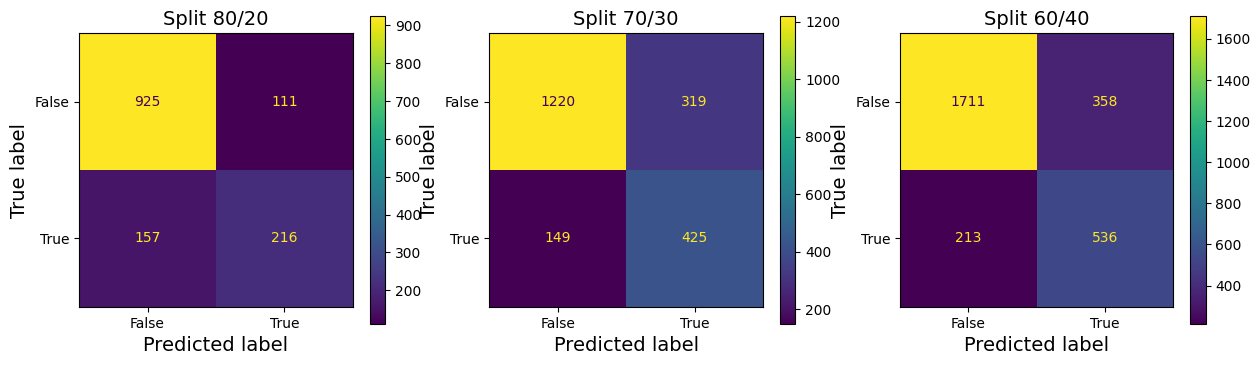

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
plt.rc('font', size=10)
for idx, split_name in enumerate(split_names):
    ConfusionMatrixDisplay.from_predictions(yTests[idx], yPreds[idx], ax=axs[idx])
    axs[idx].set_title(f"Split {split_name}")
plt.show()
plt.rc('font', size=14)

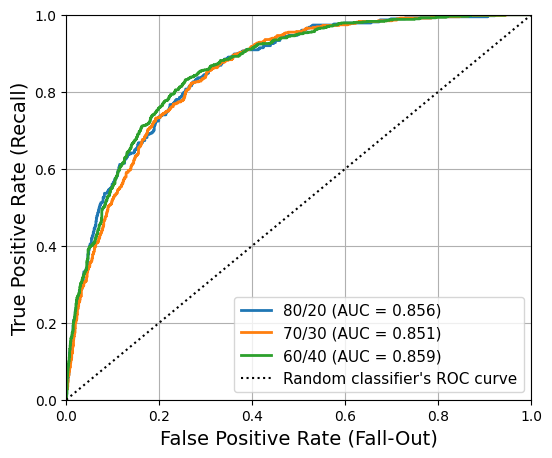

In [17]:
plt.figure(figsize=(6, 5))
for idx, split_name in enumerate(split_names):
    fpr, tpr, thresholds = roc_curve(yTests[idx], yScoresAll[idx])
    auc = roc_auc_score(yTests[idx], yScoresAll[idx])
    plt.plot(fpr, tpr, linewidth=2, label=f"{split_name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=11)
plt.show()

In [18]:
for idx, split_name in enumerate(split_names):
    yTest, yPred, yScores = yTests[idx], yPreds[idx], yScoresAll[idx]
    print(f"{split_name}  "
          f"accuracy: {(yPred == yTest).mean():.2%}  "
          f"precision: {precision_score(yTest, yPred):.2%}  "
          f"recall: {recall_score(yTest, yPred):.2%}  "
          f"f1: {f1_score(yTest, yPred):.2%}  "
          f"ROC-AUC: {roc_auc_score(yTest, yScores):.3f}")

80/20  accuracy: 80.98%  precision: 66.06%  recall: 57.91%  f1: 61.71%  ROC-AUC: 0.856
70/30  accuracy: 77.85%  precision: 57.12%  recall: 74.04%  f1: 64.49%  ROC-AUC: 0.851
60/40  accuracy: 79.74%  precision: 59.96%  recall: 71.56%  f1: 65.25%  ROC-AUC: 0.859


## Comparing StandardScaler with MinMaxScaler

In [19]:
from sklearn.preprocessing import MinMaxScaler

minmax_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
])
minmax_pipe = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", minmax_num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ])),
    ("sgd_clf", SGDClassifier(loss="log_loss", random_state=42))
])

for test_size, split_name in zip(test_sizes, split_names):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                        random_state=42)
    model = clone(minmax_pipe)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]
    print(f"MinMaxScaler {split_name}  "
          f"accuracy: {(y_pred == y_test).mean():.2%}  "
          f"recall: {recall_score(y_test, y_pred):.2%}  "
          f"ROC-AUC: {roc_auc_score(y_test, y_scores):.3f}")

MinMaxScaler 80/20  accuracy: 80.55%  recall: 37.80%  ROC-AUC: 0.850
MinMaxScaler 70/30  accuracy: 77.28%  recall: 76.66%  ROC-AUC: 0.851
MinMaxScaler 60/40  accuracy: 80.45%  recall: 46.86%  ROC-AUC: 0.856


## 2D decision boundary (tenure vs MonthlyCharges)

In [20]:
X_2d = df[["tenure", "MonthlyCharges"]].values
y_2d = df["ChurnFlag"].values
X_train, X_test, y_train, y_test = train_test_split(X_2d, y_2d, test_size=0.2,
                                                    random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

sgd_2d = SGDClassifier(loss="log_loss", random_state=42)
sgd_2d.fit(X_train_scaled, y_train)

SGDClassifier(loss='log_loss', random_state=42)

In [21]:
# coefficients for [tenure, MonthlyCharges]: positive pushes towards churn, negative towards staying
sgd_2d.intercept_, sgd_2d.coef_

(array([-1.48827708]), array([[-1.33116922,  1.19836138]]))

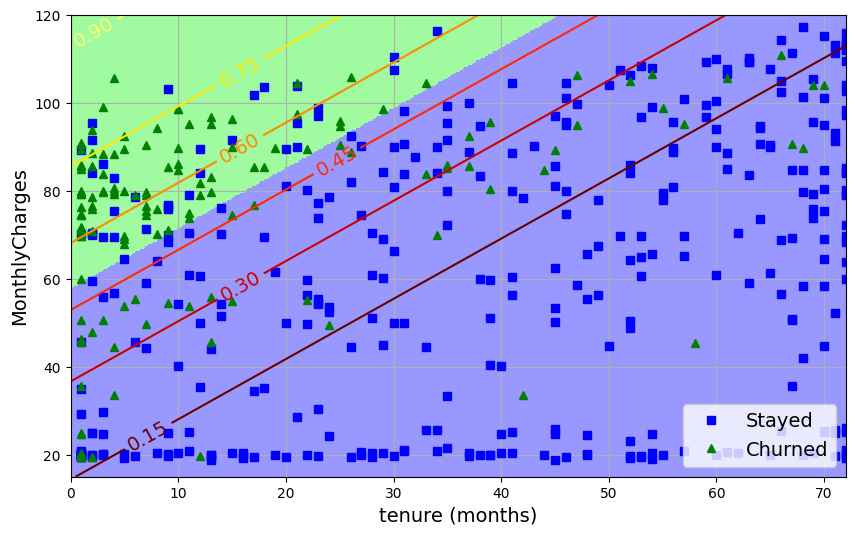

In [22]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#9898ff", "#a0faa0"])  # blue = stay, green = churn

# for the contour plot
x0, x1 = np.meshgrid(np.linspace(0, 72, 500).reshape(-1, 1),
                     np.linspace(15, 120, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]  # one instance per point on the figure
X_new_scaled = scaler.transform(X_new)

y_proba = sgd_2d.predict_proba(X_new_scaled)
y_predict = sgd_2d.predict(X_new_scaled)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

X_show, y_show = X_test[:500], y_test[:500]  # first 500 test customers, for readability

plt.figure(figsize=(10, 6))
plt.plot(X_show[y_show == 0, 0], X_show[y_show == 0, 1], "bs", label="Stayed")
plt.plot(X_show[y_show == 1, 0], X_show[y_show == 1, 1], "g^", label="Churned")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("tenure (months)")
plt.ylabel("MonthlyCharges")
plt.legend(loc="lower right")
plt.axis([0, 72, 15, 120])
plt.grid()
plt.show()